In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sfreq = 32
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.5, fmax=16)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.656 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


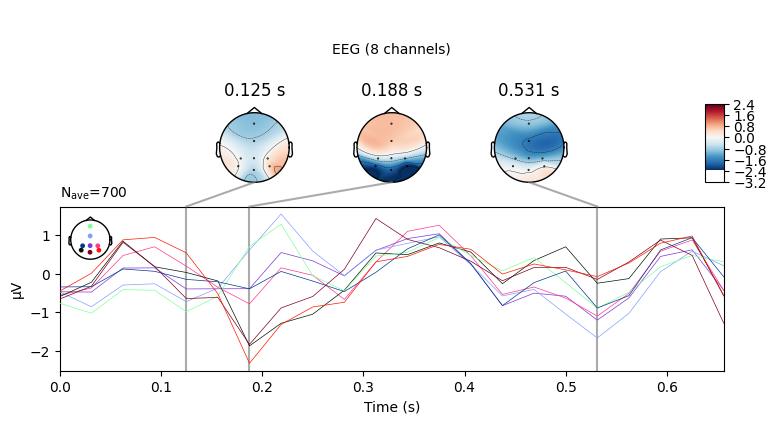

No projector specified for this dataset. Please consider the method self.add_proj.


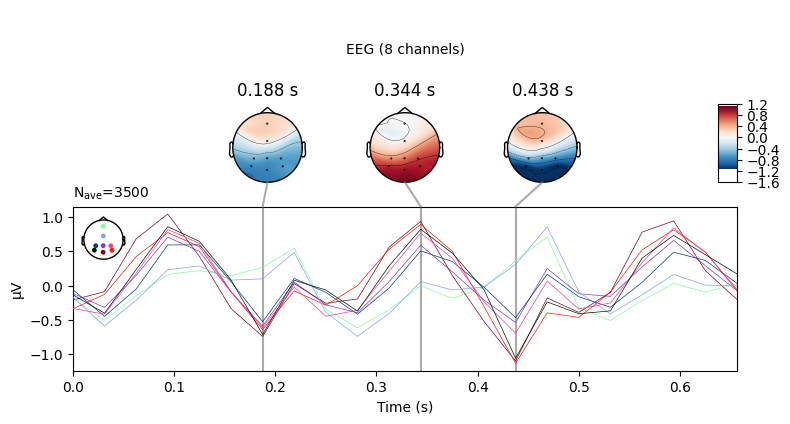

No projector specified for this dataset. Please consider the method self.add_proj.


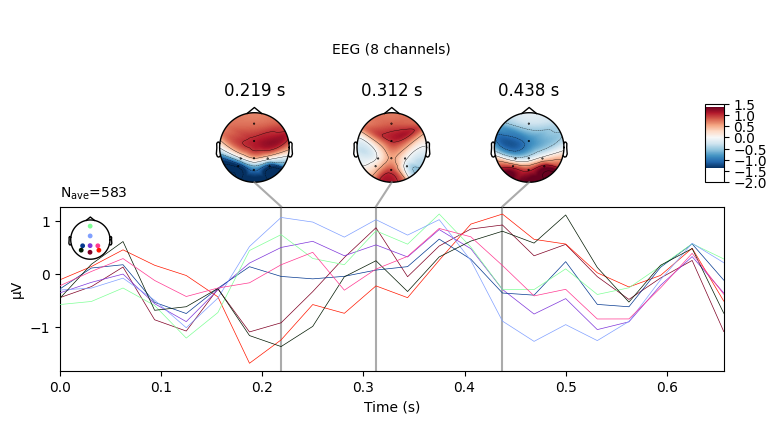

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint()
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
X_train = epochs_train.get_data().astype(np.float32)
y_train = labels_train
X_test = epochs_test.get_data().astype(np.float32)
y_test = labels_test

In [8]:
X_train -= np.mean(X_train, axis=0)[np.newaxis,:,:]
X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test -= np.mean(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

In [9]:
import tensorly as tl
try:
    tl.set_backend('jax')
except AttributeError:
    tl.set_backend('jax')

In [10]:
hoda = HODA(max_iter=256, rank=(3,3), tol=0,
            initialize ='identity', verbose=True, toeplitz=None, shrinkage='lw')
hoda.fit(X_train,y_train)

/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/jax/_src/ops/scatter.py:87: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32. In future JAX releases this will result in an error.
  warnings.warn("scatter inputs have incompatible types: cannot safely cast "


[0/256]  shrinkage[0]=0.0005  shrinkage[1]=0.0125  step=2.5834e+00  objective=0.0000e+00
[1/256]  shrinkage[0]=0.0007  shrinkage[1]=0.0214  step=2.6964e+00  objective=0.0000e+00
[2/256]  shrinkage[0]=0.0007  shrinkage[1]=0.0184  step=2.0690e+00  objective=0.0000e+00
[3/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0222  step=1.7808e+00  objective=0.0000e+00
[4/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0284  step=1.7268e+00  objective=0.0000e+00
[5/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0208  step=1.7086e+00  objective=0.0000e+00
[6/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0263  step=3.8074e-01  objective=0.0000e+00
[7/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0212  step=3.3019e-01  objective=0.0000e+00
[8/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0252  step=2.6137e-01  objective=0.0000e+00
[9/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0218  step=2.3358e-01  objective=0.0000e+00
[10/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0244  step=1.8773e-01  objective=0.0000e+00
[11/256]  shrinkage[

[91/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=3.4705e-09  objective=0.0000e+00
[92/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=2.4213e-09  objective=0.0000e+00
[93/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=2.2226e-09  objective=0.0000e+00
[94/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=1.5506e-09  objective=0.0000e+00
[95/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=1.4234e-09  objective=0.0000e+00
[96/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=9.9307e-10  objective=0.0000e+00
[97/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=9.1154e-10  objective=0.0000e+00
[98/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=6.3595e-10  objective=0.0000e+00
[99/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=5.8375e-10  objective=0.0000e+00
[100/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=4.0726e-10  objective=0.0000e+00
[101/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=3.7384e-10  objective=0.0000e+00
[102/256

[183/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=1.1885e-14  objective=0.0000e+00
[184/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=1.6995e-14  objective=0.0000e+00
[185/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=8.8279e-15  objective=0.0000e+00
[186/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=9.7386e-15  objective=0.0000e+00
[187/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=1.1191e-14  objective=0.0000e+00
[188/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=1.3846e-14  objective=0.0000e+00
[189/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=1.7674e-14  objective=0.0000e+00
[190/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=9.6698e-15  objective=0.0000e+00
[191/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=2.0478e-14  objective=0.0000e+00
[192/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=1.8706e-14  objective=0.0000e+00
[193/256]  shrinkage[0]=0.0006  shrinkage[1]=0.0211  step=2.0097e-14  objective=0.0000e+00

HODA(max_iter=256, rank=(3, 3), toeplitz=None, tol=0, verbose=True)

##### 

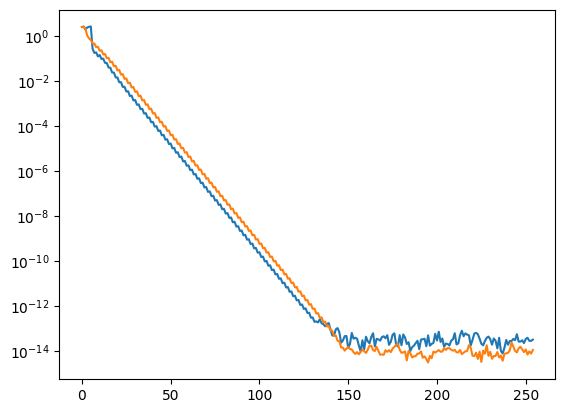

In [11]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

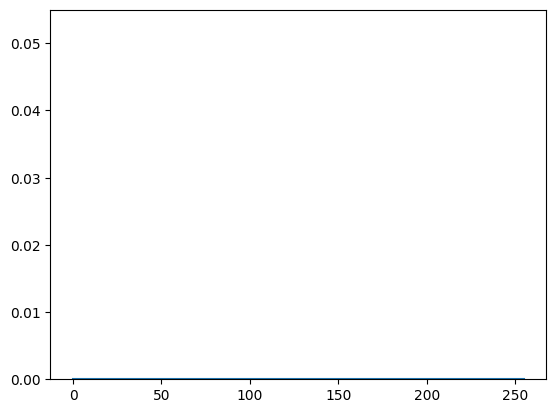

In [12]:
plt.plot(hoda.objective_)
plt.ylim([0,None])
plt.show()

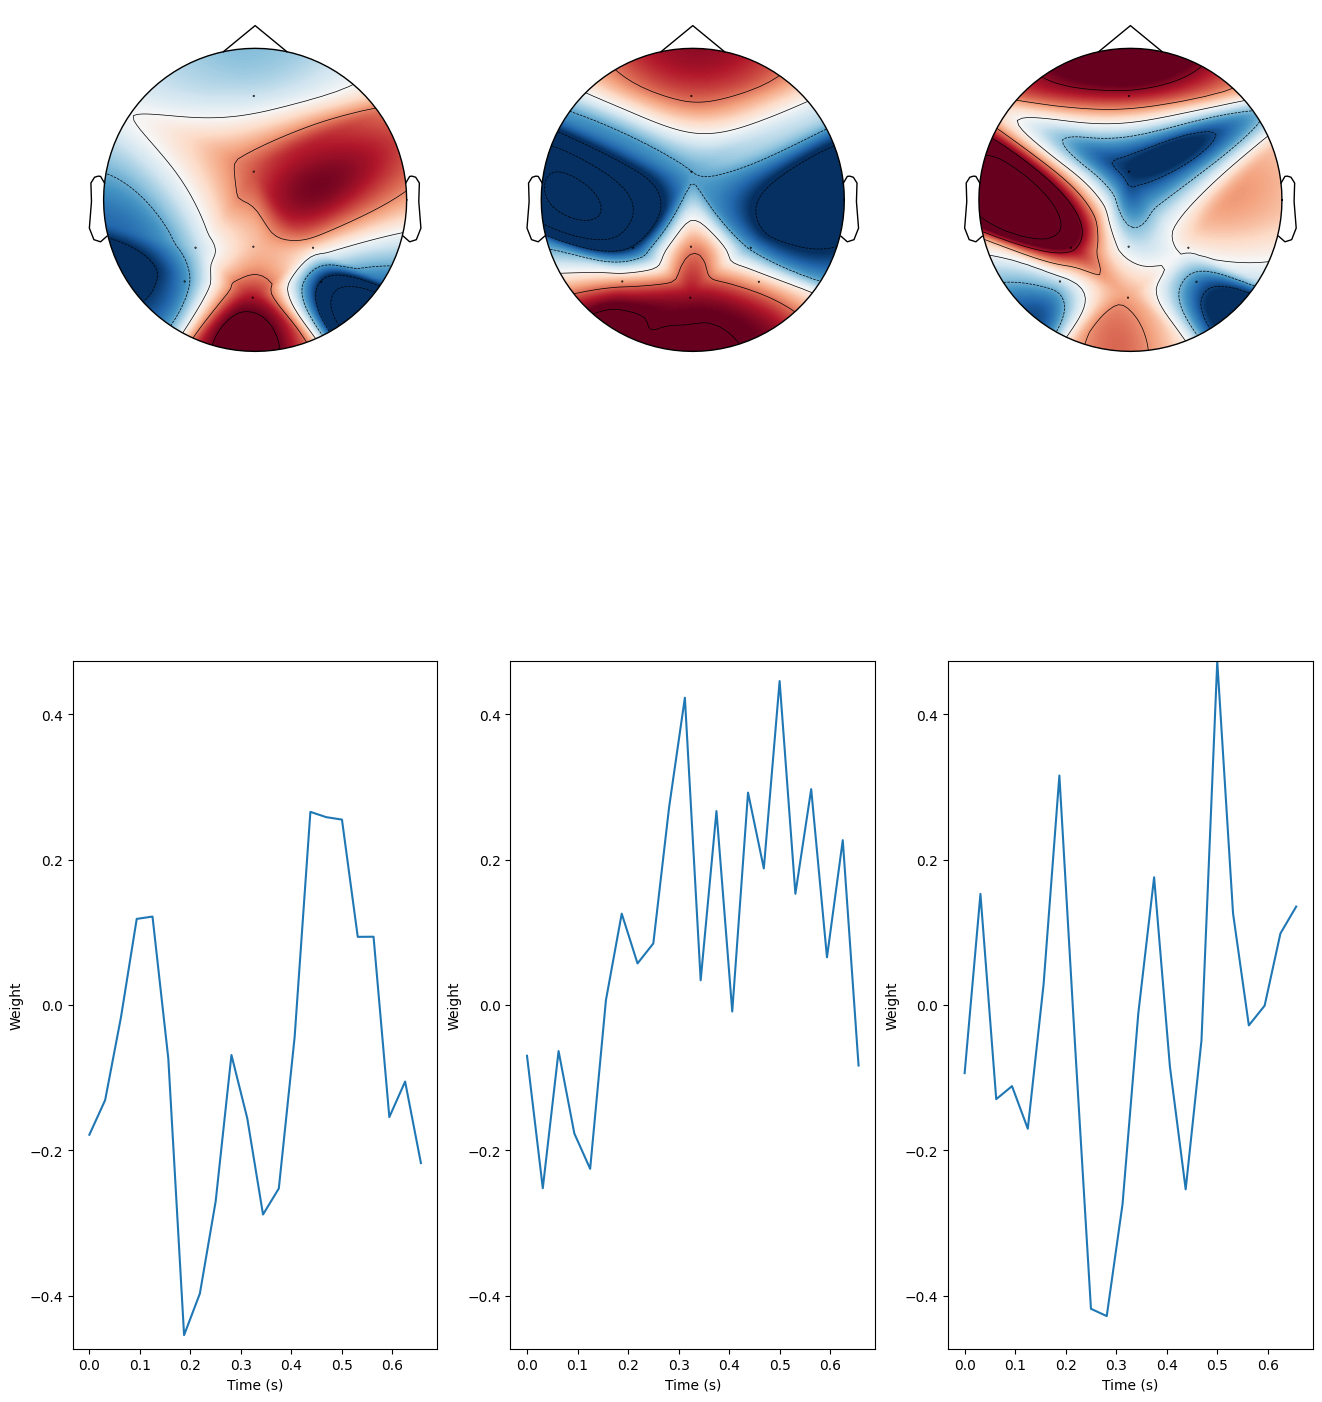

In [13]:
fig, axs = plt.subplots(2,max(hoda.rank), figsize=(16,6*3))
projs = [p for p in hoda.projs_]
for i in range(hoda.rank[0]):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank[1]):
    w = projs[1][:,i]
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])


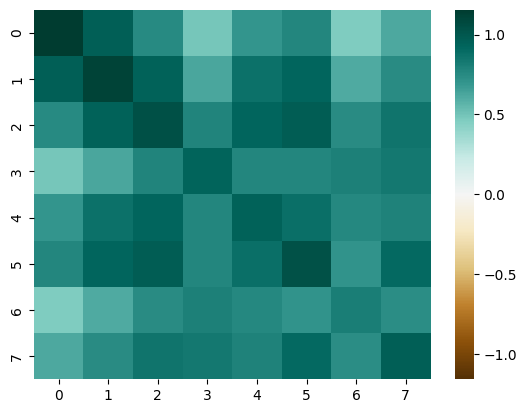

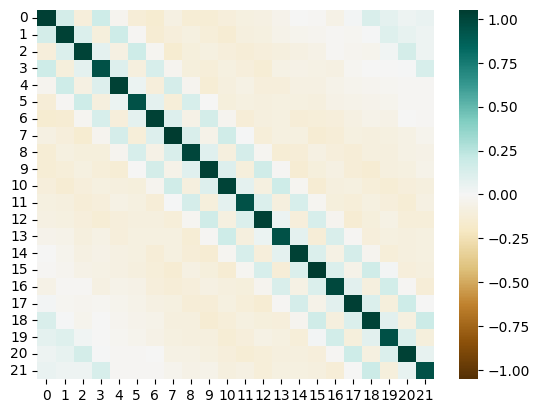

In [14]:
for k in range(2):
    cov = hoda.scatter_w_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

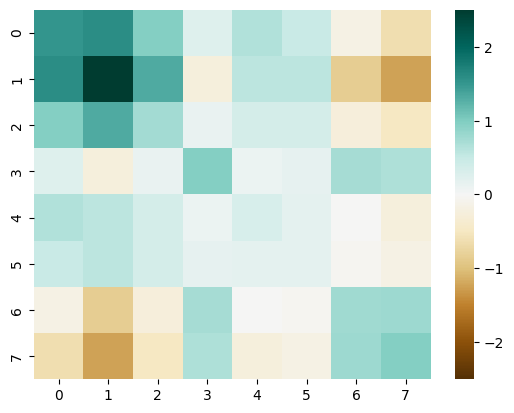

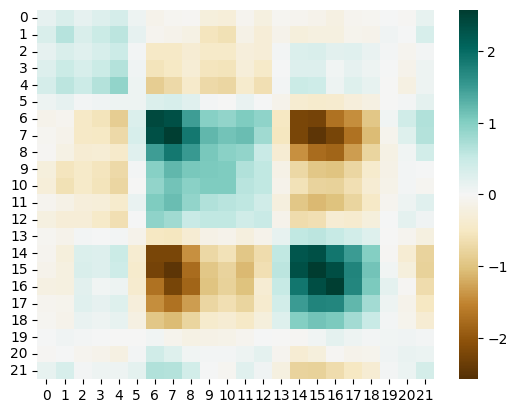

In [15]:
for k in range(2):
    cov = hoda.scatter_b_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

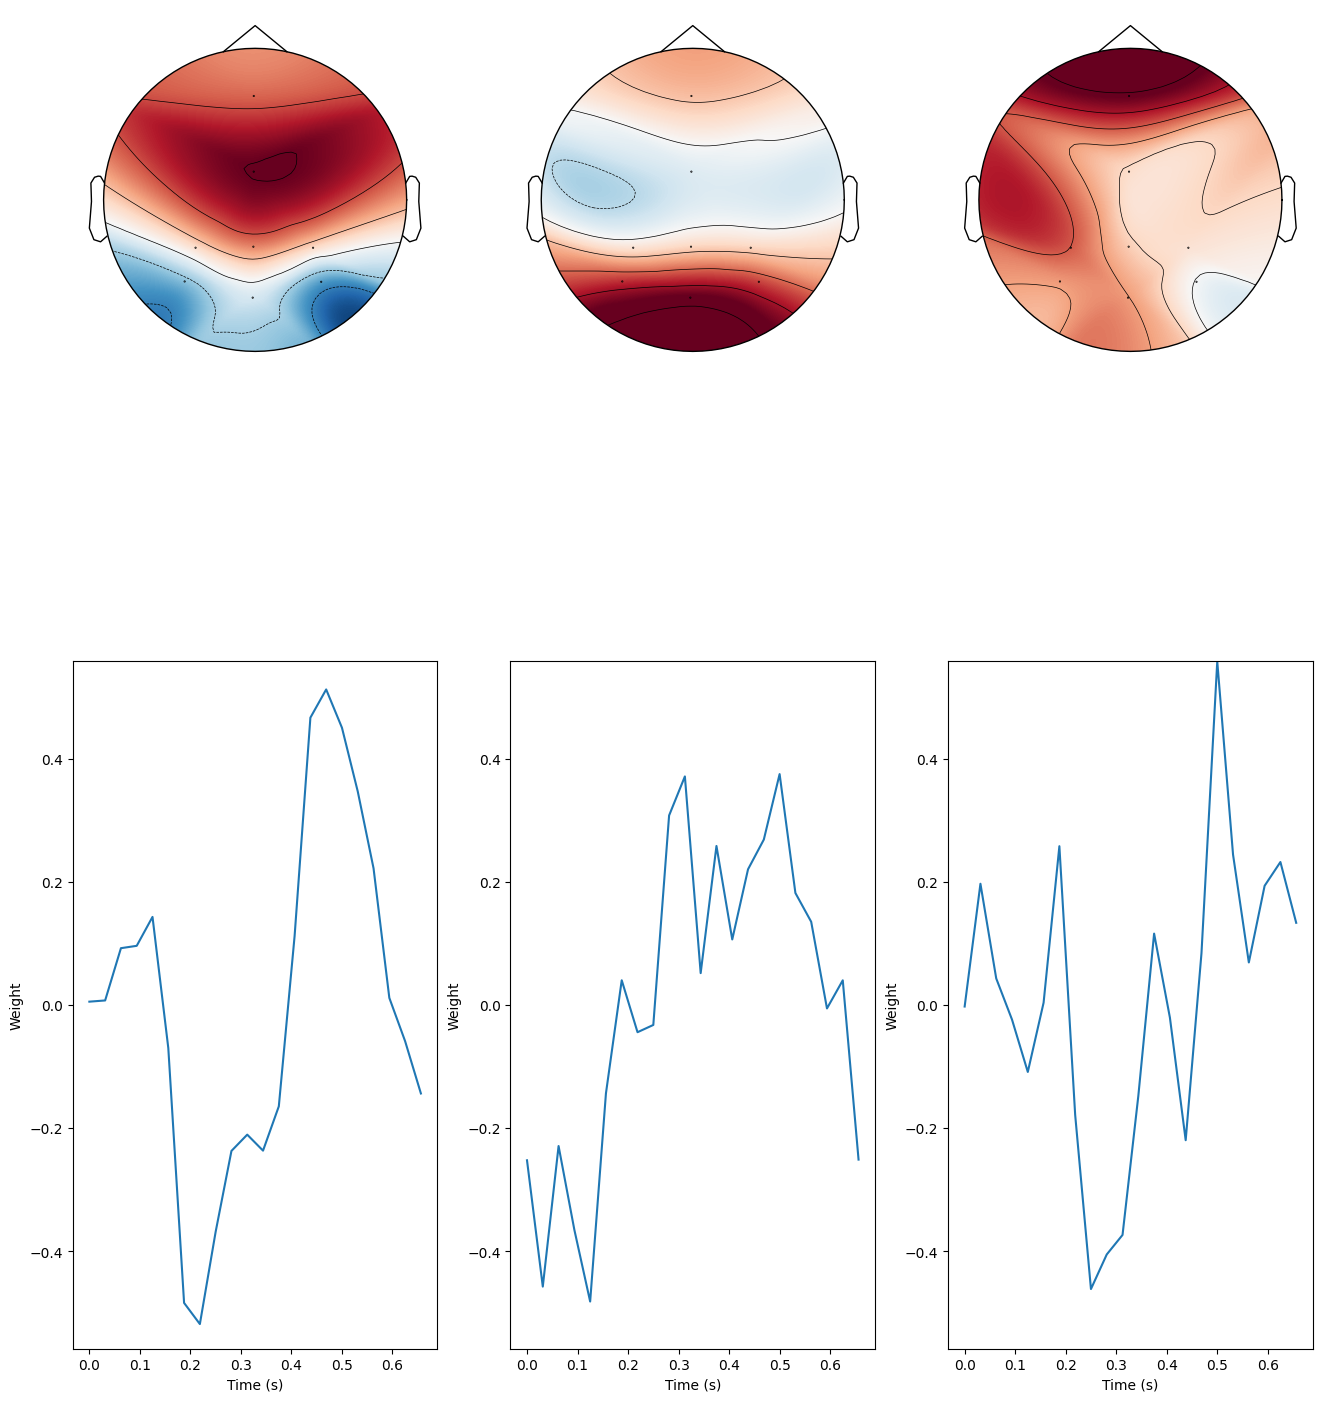

In [16]:
fig, axs = plt.subplots(2,max(hoda.rank), figsize=(16,6*3))
aps = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank[0]):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank[1]):
    w = aps[1][:,i]
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])

In [17]:
Xt_train = hoda.transform(tl.tensor(X_train))
Xt_test = hoda.transform(tl.tensor(X_test))

In [18]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier.fit(Xt_train,y_train)

LogisticRegression(penalty='l1', solver='liblinear')

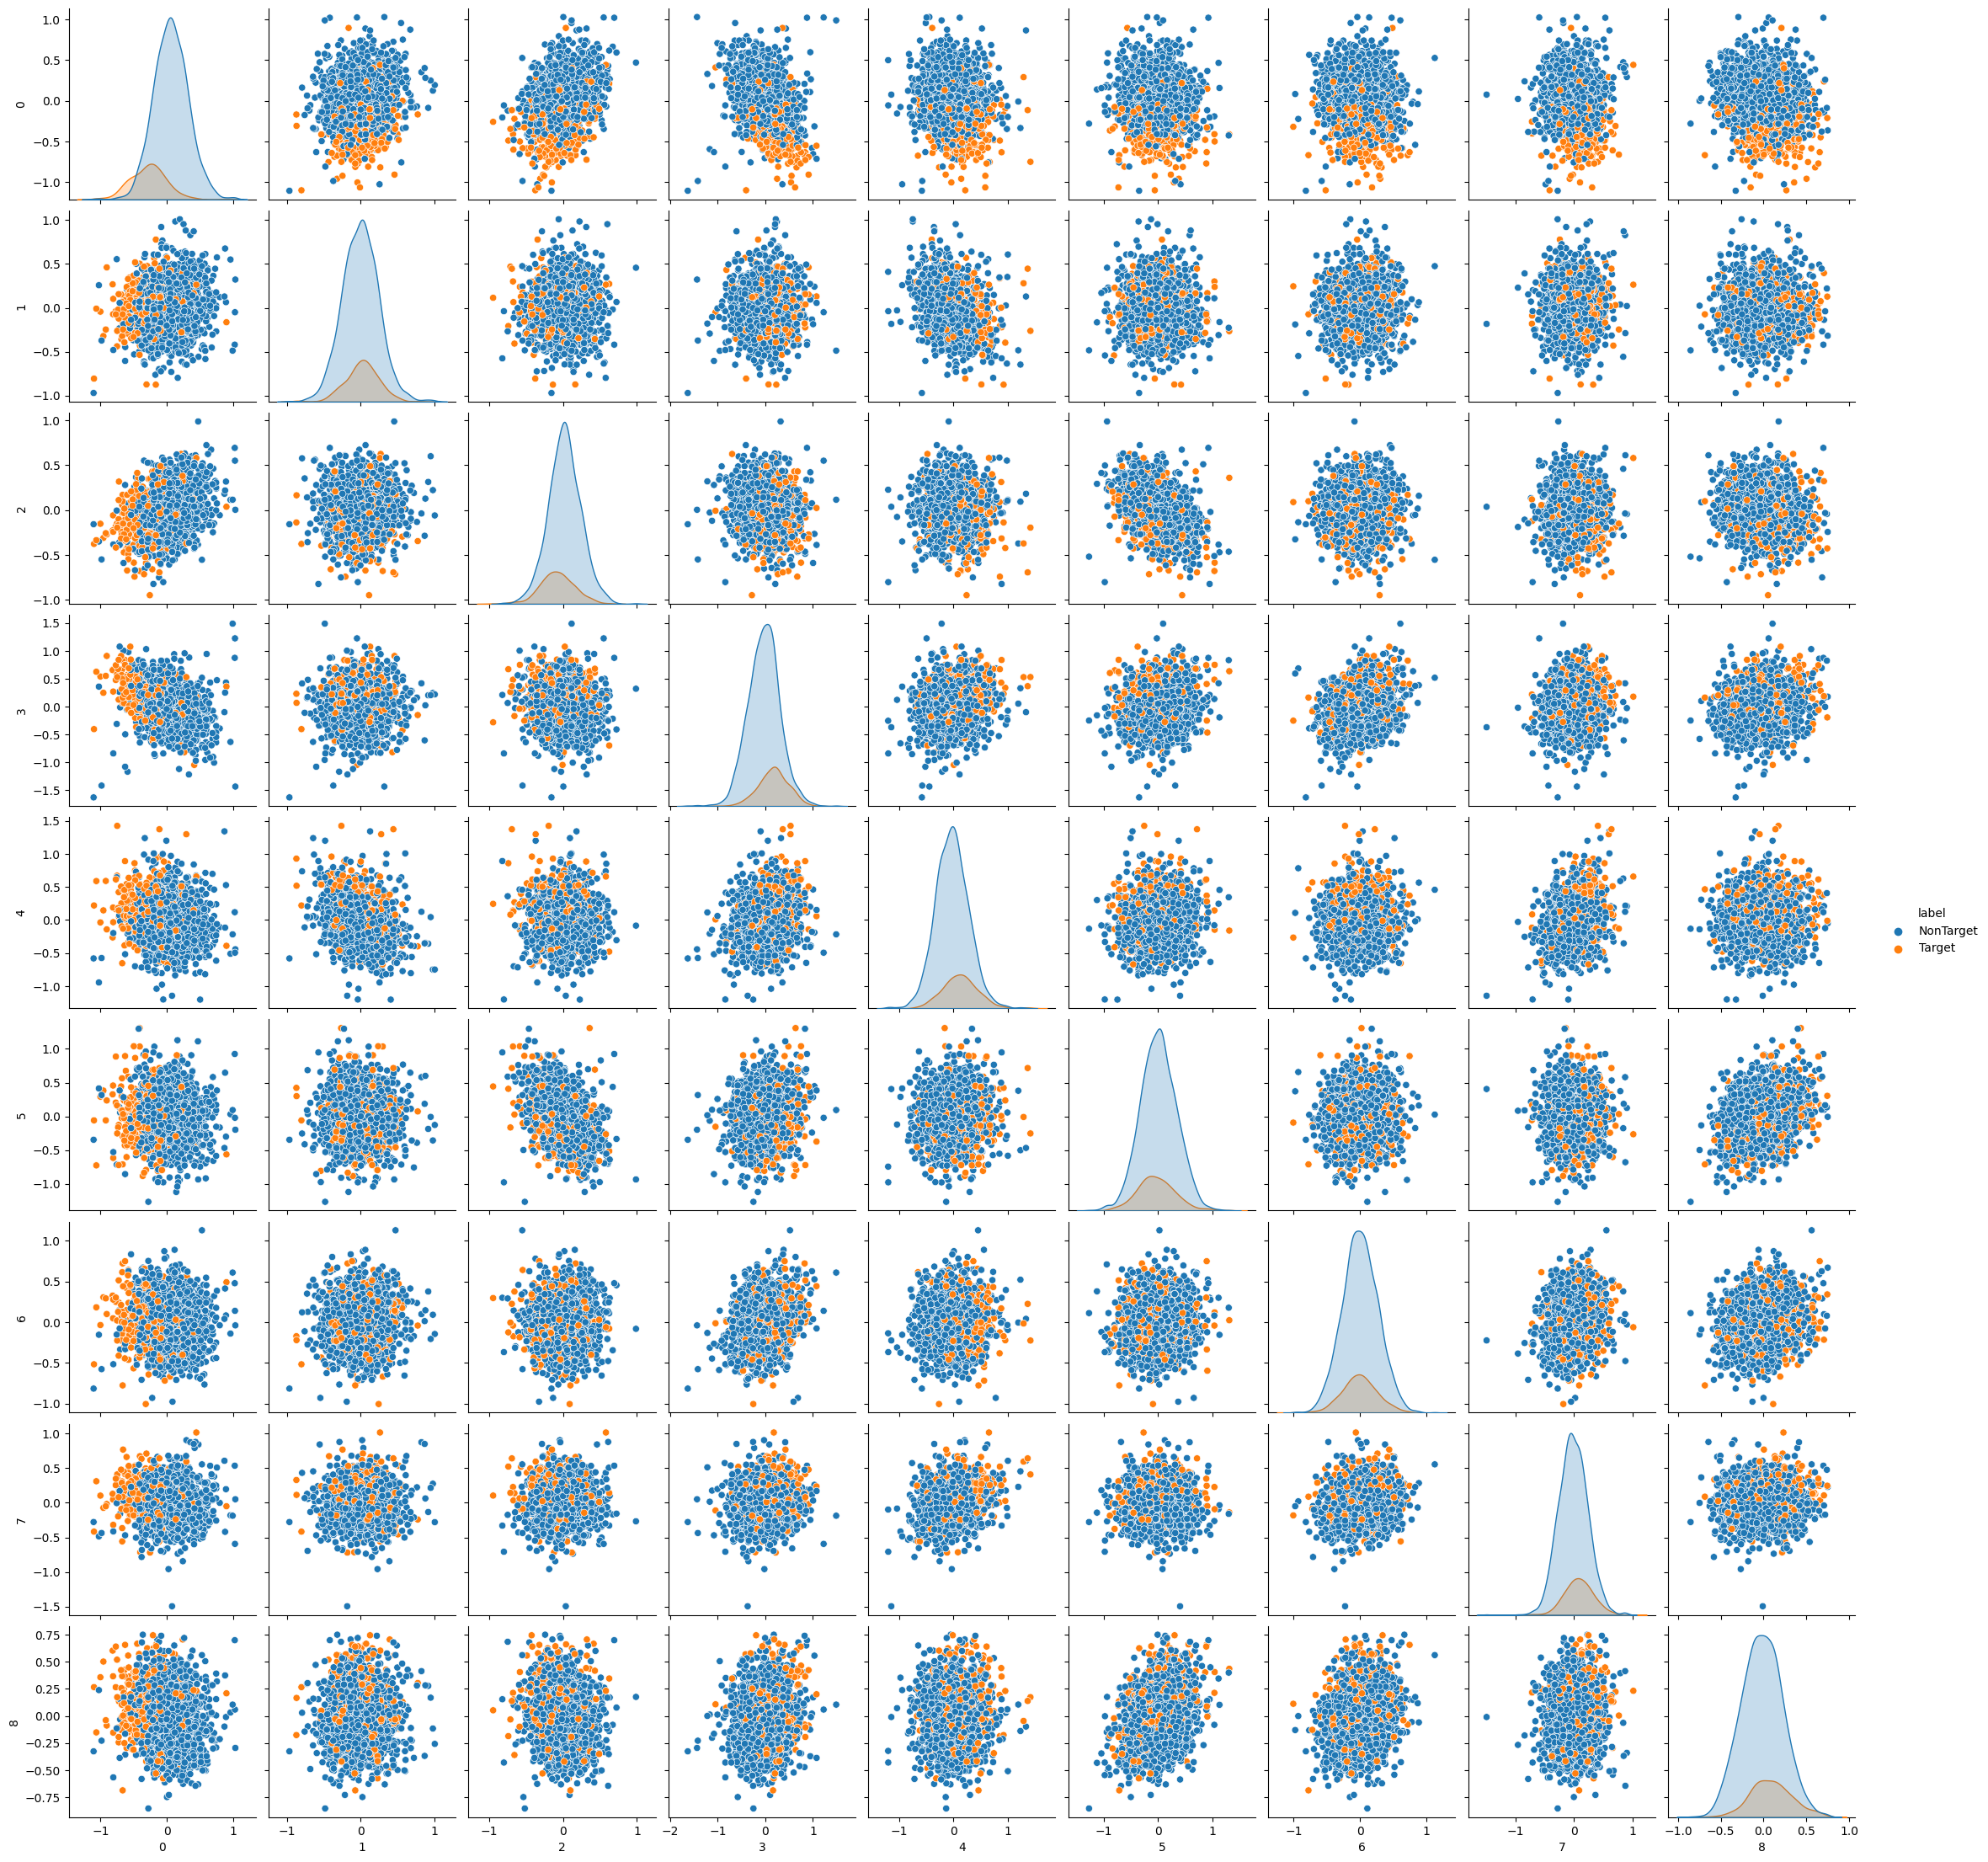

In [19]:
import seaborn as sns
import pandas as pd

Xt_train = hoda.transform(tl.tensor(X_train))
n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train)
df_train['label'] = y_train
sns.pairplot(df_train, hue='label')

In [20]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.8670171428571428

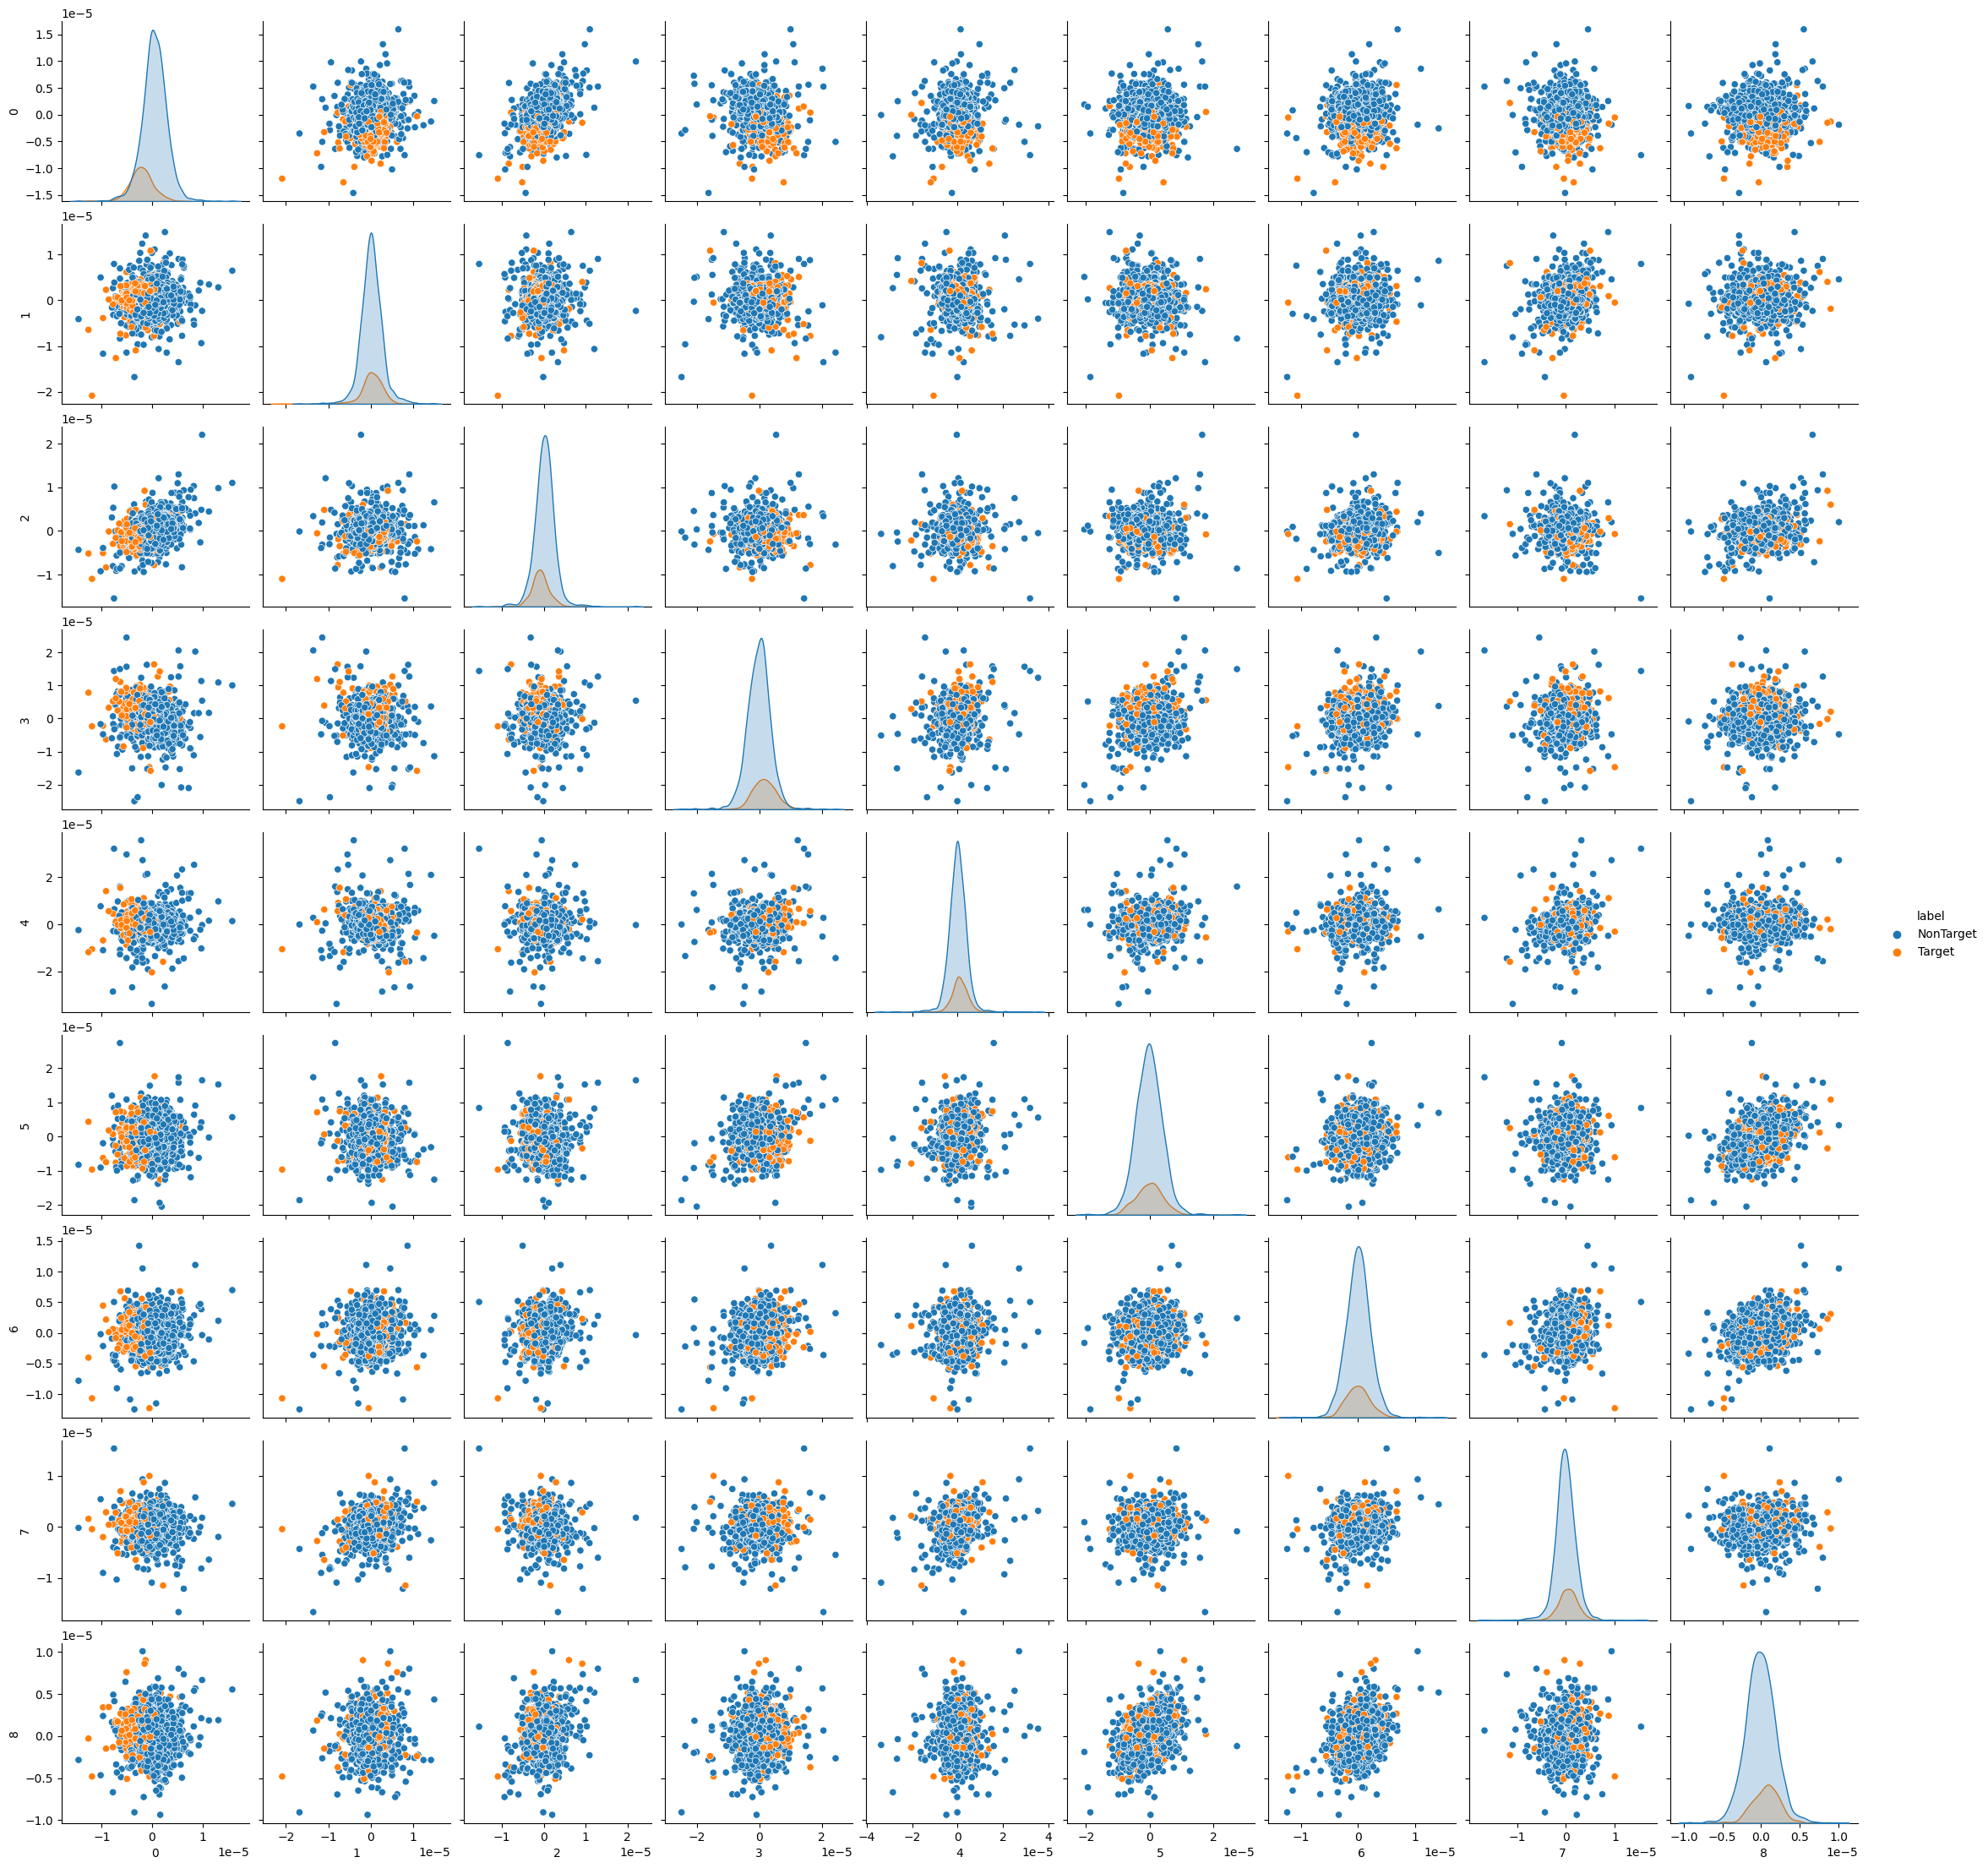

In [21]:
Xt_test = hoda.transform(tl.tensor(X_test))
df_test = pd.DataFrame(Xt_test)
df_test['label'] = y_test
sns.pairplot(df_test, hue='label')

In [22]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.8131542857142856